# Сборный проект
Самое время вспомнить знания, полученные в курсе, и решить ещё один аналитический кейс.<br>
# Описание проекта
Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Вам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании. <br>

# Этапы выполнени проекта
<b>Шаг 1. Открыть файл с данными, изучить общую информацию.<br></b>
`Путь к файлу: /datasets/games.csv` <br><br>
<b>Шаг 2. Подготовить данные.<br></b>

<b>Шаг 3. Провести исследовательский анализ данных.<br></b>

<b>Шаг 4. Составить портрет пользователя каждого региона.<br></b>

<b>Шаг 5. Проверить гипотезы.<br></b>

<b>Шаг 6. Напишите общий вывод<br></b>
Оформление: Выполните задание в Jupyter Notebook. Заполните программный код в ячейках типа code, текстовые пояснения — в ячейках типа markdown. Примените форматирование и заголовки.<br>
# Описание данных
`Name` — название игры<br>
`Platform` — платформа<br>
`Year_of_Release` — год выпуска<br>
`Genre` — жанр игры<br>
`NA_sales` — продажи в Северной Америке (миллионы проданных копий)<br>
`EU_sales` — продажи в Европе (миллионы проданных копий)<br>
`JP_sales` — продажи в Японии (миллионы проданных копий)<br>
`Other_sales` — продажи в других странах (миллионы проданных копий)<br>
`Critic_Score` — оценка критиков (максимум 100)<br>
`User_Score` — оценка пользователей (максимум 10)<br>
`Rating` — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.<br>
Данные за 2016 год могут быть неполными.


## Шаг. Открыть файл с данными, изучить общую информацию

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
#формат показателей с плавающей точкой:
pd.set_option('display.float_format', '{:,.2f}'.format)

#Снятие ограничений на отображения количества колонок:
pd.set_option('display.max_columns', None) 

#Снятие ограничений на отображения количества колонок:
#pd.set_option('display.max_rows', None) 

sns.set_theme(rc={'figure.figsize':(10,6)})

In [2]:
df = pd.read_csv('/datasets/games.csv')

In [3]:
#Заведем функцию для первичного осмотра:
def first_look(check):
    long = len(check)
    if long < 10:
        print('Вывод таблицы:')
        display(check)
    else:
        print('Вывод первых 5 строк таблицы:')
        display(check.head(5))
        print('Вывод последних 5 строк таблицы:')
        display(check.tail(5))

    print('\nТипы данных:\n')
    check.info()
    print('\nКоличество уникальных значений по колонкам:\n')
    for k in check.columns:
        print(f'{k}: {check[k].nunique()}')
    print('\nСтатистическая сводка:')
    display(check.describe())
    print('\nПропуски:')
    display(check.isna().sum())    
    print(f'\nКоличество полных дубликатов: {check.duplicated().sum()}\n')
    
    check.hist(figsize=(15,20), bins = 20)
    plt.show()

Вывод первых 5 строк таблицы:


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Вывод последних 5 строк таблицы:


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16710,Samurai Warriors: Sanada Maru,PS3,"2,016.00",Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,"2,006.00",Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,"2,016.00",Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,"2,003.00",Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN
16714,Winning Post 8 2016,PSV,"2,016.00",Simulation,0.00,0.00,0.01,0.00,NaN,NaN,NaN



Типы данных:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

Количество уникальных значений по колонкам:

Name: 11559
Platform: 31
Year_of_Release: 37
Genre: 12
NA_sales: 402
EU_sales: 307
JP_sales: 244
Other_sales: 155
Critic_Score: 82
User_Score: 96
Rating: 8

Статистическая сводка:


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,"16,446.00","16,715.00","16,715.00","16,715.00","16,715.00","8,137.00"
mean,"2,006.48",0.26,0.15,0.08,0.05,68.97
std,5.88,0.81,0.50,0.31,0.19,13.94
min,"1,980.00",0.00,0.00,0.00,0.00,13.00
25%,"2,003.00",0.00,0.00,0.00,0.00,60.00
50%,"2,007.00",0.08,0.02,0.00,0.01,71.00
75%,"2,010.00",0.24,0.11,0.04,0.03,79.00
max,"2,016.00",41.36,28.96,10.22,10.57,98.00



Пропуски:


Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64


Количество полных дубликатов: 0



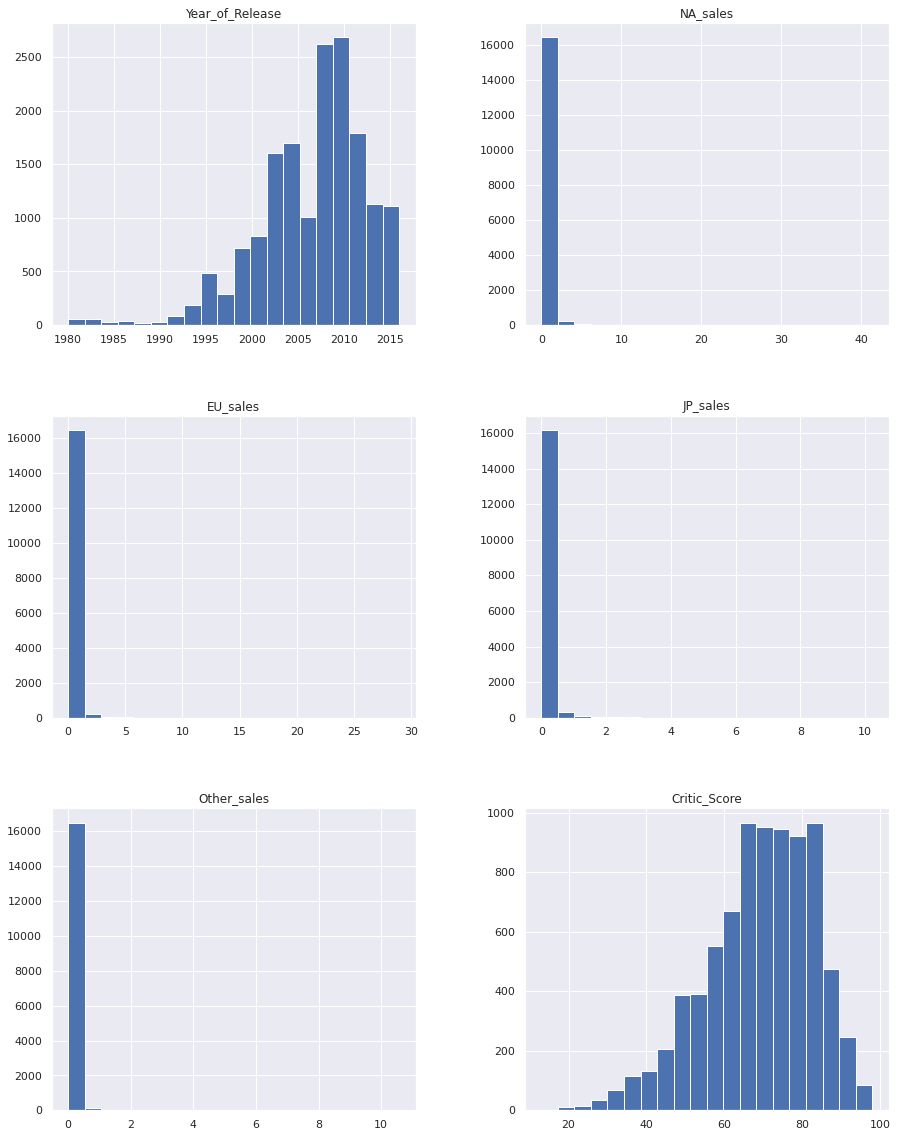

In [4]:
first_look(df)

Имеются пропуски в названиях игр. Проверим:

In [5]:
df[df['Name'].isna()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
659,NaN,GEN,"1,993.00",NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,"1,993.00",NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Полагаю от 2х записей без данных можно избавиться. Вряд ли они ни на что-то влияют.

In [6]:
df = df[~df['Name'].isna()].reset_index(drop=True)
df

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16708,Samurai Warriors: Sanada Maru,PS3,"2,016.00",Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16709,LMA Manager 2007,X360,"2,006.00",Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16710,Haitaka no Psychedelica,PSV,"2,016.00",Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,Spirits & Spells,GBA,"2,003.00",Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [7]:
#Также, проверим на неявные дубли:
df[df.duplicated(subset=['Name','Platform','Year_of_Release'])]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16228,Madden NFL 13,PS3,"2,012.00",Sports,0.00,0.01,0.00,0.00,83.00,5.5,E


Выявлена 1 игра. рассмотрим подробнее:

In [8]:
df[(df['Name']=='Madden NFL 13') & (df['Platform']=='PS3')]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
604,Madden NFL 13,PS3,"2,012.00",Sports,2.11,0.22,0.00,0.23,83.00,5.5,E
16228,Madden NFL 13,PS3,"2,012.00",Sports,0.00,0.01,0.00,0.00,83.00,5.5,E


Полагаю, стоит удалить второй "экземпляр"

In [9]:
#Удаление:
df=df.drop_duplicates(subset=['Name','Platform','Year_of_Release'], keep='first').reset_index(drop=True)

#Повторная проверка на дубли:
print('Осталось дублей:',df[df.duplicated(subset=['Name','Platform','Year_of_Release'])]['Name'].sum())

Осталось дублей: 0


<b>Вывод:</b><br>
1. В дф 16715 записей - достаточно для проведения анализа.
2. Имеются пропущенные данные в нескольких колонках.
3. Выявлены не заполненые ячейки. Требуется заполнение "заглушками".
4. Имеет смысл изменить тип данных нескольких колонок.
5. Требуется наименование колонок привести к нижнему регистру.
6. Большая часть игр продавалось менее 1 млн копий на регион, но наблюдаются аномально высокие максимальные значения продаж некоторых игр.
7. Присутствовало 2 записи с неприсвоенными играми - удалил.
8. Удалён не явный дубль.

## Шаг. Подготовить данные

In [10]:
# Приведение названия колонок к нижнему регистру:
df.columns = [x.lower() for x in df.columns]

# Проверим назваения колонок:
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

Одна игра может встречаться несколько раз (1 раз для каждой платформы, на которой игра выходила). Проверим, что данные отсутствуют у всех платформ для каждой игры. Начнем с колонки `year_of_release`.

In [11]:
#Заведем список игр, у которых есть присвоенный год релиза игры:
games_with_release_date_list = df[~df['year_of_release'].isna()][['name','year_of_release']]

# Выведем информацию о количестве игр в списке:
print('Всего записей с присвоенной датой релиза игры, включая дубли по платформам -',len(games_with_release_date_list))

# удалим дубли:
games_with_release_date_list = games_with_release_date_list.drop_duplicates()

print('Всего записей с присвоенной датой релиза игры, после удаления дублей всего -',len(games_with_release_date_list))

#Выведем 5 игр, которые после удаления дублей имеют несколько дат релиза:
games_with_release_date_list['name'].value_counts().head(5)

Всего записей с присвоенной датой релиза игры, включая дубли по платформам - 16443
Всего записей с присвоенной датой релиза игры, после удаления дублей всего - 12195


SimCity 2000         5
Monopoly             5
Jeopardy!            4
MotoGP               4
Final Fantasy III    4
Name: name, dtype: int64

Получается, что имеются игры с несколькими датами релиза. Полагаю связано с их популярностью, а также тем, что они переиздавались для новых платформ. Проверим теорию на игре `Монополия`:

In [12]:
df[df['name']=='Monopoly']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
658,Monopoly,PC,"1,994.00",Misc,1.49,0.81,0.00,0.10,NaN,NaN,NaN
912,Monopoly,Wii,"2,008.00",Misc,0.86,0.83,0.00,0.20,70.00,7.8,E
1249,Monopoly,PS,"1,997.00",Misc,1.18,0.27,0.00,0.05,NaN,NaN,NaN
3382,Monopoly,X360,"2,008.00",Misc,0.34,0.20,0.00,0.06,56.00,5.8,E
4521,Monopoly,PS2,"2,008.00",Misc,0.21,0.16,0.00,0.05,NaN,7.2,E
5389,Monopoly,PS3,"2,008.00",Misc,0.25,0.05,0.00,0.04,54.00,6.7,E
6340,Monopoly,DS,"2,010.00",Misc,0.15,0.09,0.00,0.02,NaN,tbd,NaN
7397,Monopoly,N64,"1,999.00",Misc,0.17,0.04,0.00,0.00,NaN,NaN,NaN


Полагаю, теория подтвердилась. Одновременно, можно заметить, что рейтинги для каждой платформы также различаются.
Это что касается `Монополии`, которая изначально настольная игра, перенесенная на различные платформы. Продолжим изучение вопроса: можно ли подтянуть год выпуска тем играм, где год не присвоен.<br>
Выведем список игр, у которых год выпуска отсутствует.

In [13]:
no_year_of_release_game_list = df[(df['year_of_release'].isna())]['name']

Совместим 2 списка.

In [14]:
cross_list = games_with_release_date_list[games_with_release_date_list['name'].isin(no_year_of_release_game_list)]
print('Всего игр, которые попали в 2 списка', len(cross_list))

#Удаление явных дублей:
cross_list = cross_list.drop_duplicates()

#Вывод количества релизов на игру:
cross_list['name'].value_counts().head(5)

Всего игр, которые попали в 2 списка 113


Wheel of Fortune                        3
Space Invaders                          3
PES 2009: Pro Evolution Soccer          2
Smashing Drive                          2
Tom and Jerry in War of the Whiskers    2
Name: name, dtype: int64

In [15]:
display(df[df['name']=='Wheel of Fortune']) #по нашему "поле чудес"
display(df[df['name']=='Tomb Raider (2013)'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1576,Wheel of Fortune,PS,"1,998.00",Misc,0.99,0.22,0.00,0.04,NaN,NaN,NaN
2123,Wheel of Fortune,Wii,"2,010.00",Misc,0.86,0.04,0.00,0.06,NaN,7.6,E
2156,Wheel of Fortune,PS2,NaN,Misc,0.47,0.36,0.00,0.12,NaN,tbd,E
4661,Wheel of Fortune,DS,"2,010.00",Misc,0.39,0.00,0.00,0.03,NaN,tbd,E
6669,Wheel of Fortune,N64,"1,997.00",Misc,0.20,0.05,0.00,0.00,NaN,NaN,NaN


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
646,Tomb Raider (2013),PS3,"2,013.00",Action,0.60,1.26,0.08,0.48,NaN,NaN,NaN
909,Tomb Raider (2013),X360,"2,013.00",Action,0.86,0.84,0.01,0.17,NaN,NaN,NaN
1383,Tomb Raider (2013),PS4,"2,014.00",Action,0.47,0.65,0.06,0.22,NaN,NaN,NaN
3308,Tomb Raider (2013),XOne,"2,014.00",Action,0.35,0.21,0.00,0.05,NaN,NaN,NaN
5335,Tomb Raider (2013),PC,NaN,Action,0.06,0.25,0.00,0.04,86.00,8.5,M


На интернет ресурсе "https://gamefaqs.gamespot.com/ps2/563104-wheel-of-fortune?validate=1" можно получить информацию , что релиз игры "Wheel of Fortune" на платформе PS2 произошел в 2003 году. Год не совпал ни с 1 из имеющихся в базе по другим платформам. Массово присваивать дату из других платформ нельзя. <br>Даже если обратить внимание на игру "Tomb Raider (2013)", у нее будет 2 разных года релиза: 2013 (PS3 и X360) и 2014 (на новых поколениях - PS4 и XOne). <br>
Вывод: Пока оставим, в конце 2 раздела посмотрим что с ними делать. <br>
Также, по указанным играм видно, что рейтинги тоже вряд ли получится подтянуть от других платформ. 

Займусь рейтингами. В `user_score` присутсвует значение "tbd" что означает "To Be Determined", что в свою очередь на русский яндекс переводчиком переводится как "Предстоит определить" - заменю на -1, чтобы вывести в отдельную группу. <br> 
Также, в колонку `rating` присвою заглушку "no_rating".

Займёмся преобразованием типов данных колонок, где требуется присвоим "целочисленный тип", где требуется присвоим с плаваюшей точкой, а в некоторых колонках - категорию.

In [16]:
# Заведем списки с колонками, в которых стоит заменить тип данных.
int_list = ['year_of_release', 'critic_score']
float_list = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'user_score']
category_list = ['genre', 'rating']

In [17]:
#заполним "затычками" где данных не хватает, испльзуем "-1", чтобы не путаться и отфильтровать во время анализа.  
df[int_list] =df[int_list].fillna(-1) 
df['user_score'] = df['user_score'].replace({'tbd':-1})
df['user_score'] = df['user_score'].fillna(-1)
df['rating'] = df['rating'].fillna('no_rating')

In [18]:
df['year_of_release'].unique()

array([ 2.006e+03,  1.985e+03,  2.008e+03,  2.009e+03,  1.996e+03,
        1.989e+03,  1.984e+03,  2.005e+03,  1.999e+03,  2.007e+03,
        2.010e+03,  2.013e+03,  2.004e+03,  1.990e+03,  1.988e+03,
        2.002e+03,  2.001e+03,  2.011e+03,  1.998e+03,  2.015e+03,
        2.012e+03,  2.014e+03,  1.992e+03,  1.997e+03,  1.993e+03,
        1.994e+03,  1.982e+03,  2.016e+03,  2.003e+03,  1.986e+03,
        2.000e+03, -1.000e+00,  1.995e+03,  1.991e+03,  1.981e+03,
        1.987e+03,  1.980e+03,  1.983e+03])

Проверим пропуски еще раз

In [19]:
df.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

Пропуски отсутствуют. Присвою тип целочисленный колонкам `year_of_release` и `critic_score`, колонке `user_score` присвою тип float (прочие float тоже переведу из float64 в 32), колонкам `genre` и `rating` присвою тип "category", так как не так много присвоенных уникальных значений, что в свою очередь уменьшит размер занимаемой памяти.
<br><br>
<b>Дополнение: </b> Менять тип в колонках `genre` и `rating` на "category" не буду, закомментил, т.к. замена на "category" привела к проблеме с визуализацией графиков.

In [20]:
df[int_list] = df[int_list].astype('int32')
df[float_list] = df[float_list].astype('float32')
#df[category_list] = df[category_list].astype('category')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16712 entries, 0 to 16711
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16712 non-null  object 
 1   platform         16712 non-null  object 
 2   year_of_release  16712 non-null  int32  
 3   genre            16712 non-null  object 
 4   na_sales         16712 non-null  float32
 5   eu_sales         16712 non-null  float32
 6   jp_sales         16712 non-null  float32
 7   other_sales      16712 non-null  float32
 8   critic_score     16712 non-null  int32  
 9   user_score       16712 non-null  float32
 10  rating           16712 non-null  object 
dtypes: float32(5), int32(2), object(4)
memory usage: 979.3+ KB


После всех преобразований типов данных объем занимаемой памяти сократился почти в 2 раза.

Добавим дополнительную колонку, с общими продажами всех регионов.

In [22]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales'] 

In [23]:
display(df.head())
df['total_sales'].dtype

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1,-1.00,no_rating,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1,-1.00,no_rating,31.38


dtype('float32')

Дополнительная колонка создана. Тип данных - float32.

Вернемся к вопросу об играх без даты релиза. Рассмотрим какую часть от общего числа строк в базе занимают эти строки, а также какая доля продаж указанных игр составляет от суммарных общих продаж.

In [24]:
tot_rows = len(df)
no_rel_rows = len(df[df['year_of_release'] > 0])
print(f'Доля строк игр, без присвоенных дат релиза составляет {no_rel_rows/tot_rows:.1%} от общего количества строк базы')

tot_sales=df['total_sales'].sum()
no_rel_sales = df[df['year_of_release'] > 0]['total_sales'].sum()
print(f'Доля продаж игр, без присвоенных дат релиза составляет {no_rel_sales/tot_sales:.0%} от общей суммы продаж')


Доля строк игр, без присвоенных дат релиза составляет 98.4% от общего количества строк базы
Доля продаж игр, без присвоенных дат релиза составляет 99% от общей суммы продаж


Полагаю, в целом, можно пренебречь указанными данными, которых в базе чуть больше 1.5%. Отфильтрую df, уберу игры без присвоенной даты. 

In [25]:
df = df[df['year_of_release']>0].reset_index(drop=True)
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1,-1.00,no_rating,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1,-1.00,no_rating,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16438,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1.00,no_rating,0.01
16439,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,-1,-1.00,no_rating,0.01
16440,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-1,-1.00,no_rating,0.01
16441,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,-1,-1.00,no_rating,0.01


<b>Выводы:<br></b>
Во время подготовки данных были проделаны следующие процедуры:
1. Названия колонок приведены к нижнему регистру.
2. Проверил можно ли подтянуть недостающую информацию от тех же игр, но на других платформах - нельзя.
3. Заполнил "заглушками" отстутствующие поля в записях.
4. Присвоил колонкам корректные типы данных.
5. Добавил колонку с суммарными продажами по всем регионам.
6. Отфильтровал часть дф с играми без присвоенного года выпуска.

## Шаг. Провести исследовательский анализ данных

In [26]:
#выведу количество игр, созданных по годам:
games_by_year = df[df['year_of_release']>-1].pivot_table(index='year_of_release', values = 'name', aggfunc='count').rename(columns={'name':'Количество'})
display(games_by_year.sort_index(ascending=False))



,Количество
year_of_release,
2016,502
2015,606
2014,581
2013,544
2012,652
2011,1136
2010,1255
2009,1426
2008,1427


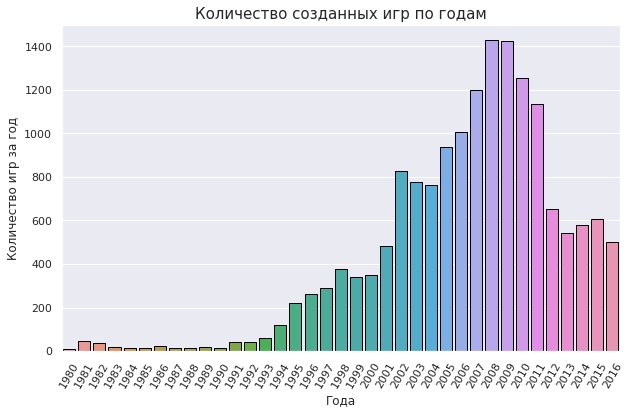

In [27]:
# отобразим на графике:
ax = sns.barplot(data = games_by_year.T, edgecolor='black')
ax.set_title('Количество созданных игр по годам', fontsize=15)
ax.set_xlabel('Года')
ax.set_ylabel('Количество игр за год')
plt.xticks(rotation=60)
plt.show()

Полагаю, рассматривать количество игр до 1994 года в принципе смысла нет. Создадим дф, в котором будут игры с датой создания от 1994 года. Но перед этим посмотрим от какой доли данных при этом откажемся.

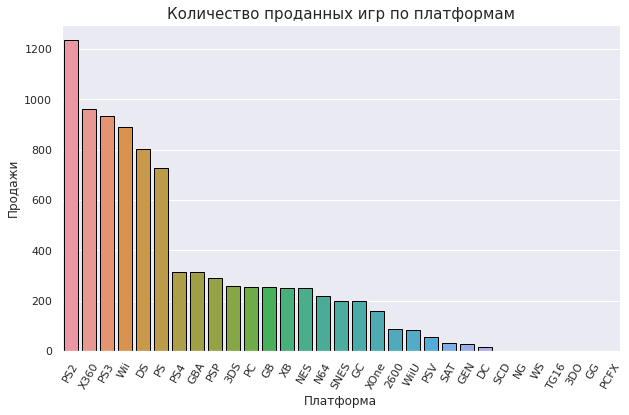

In [28]:
#Создам сводную таблицу по продажам игр по платформам:
games_by_platform = df.pivot_table(index='platform', values = 'total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False).T
# отобразим на графике:
ax = sns.barplot(data = games_by_platform, edgecolor='black')
ax.set_title('Количество проданных игр по платформам', fontsize=15)
ax.set_xlabel('Платформа')
ax.set_ylabel('Продажи')
plt.xticks(rotation=60)
plt.show()

Платформами - лидерами продаж игр являются:

In [29]:
leaders = games_by_platform.T.head(6)
leaders

,total_sales
platform,
PS2,"1,233.56"
X360,961.24
PS3,931.33
Wii,891.18
DS,802.78
PS,727.58


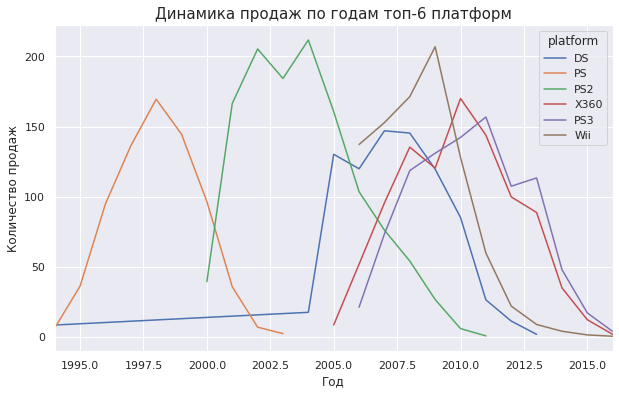

In [30]:
#Создадим сводную таблицу по продажам топ-6 платформ:
pivot_pl = df[df['platform'].isin(leaders.index)].pivot_table(index=['year_of_release','platform'], values='total_sales', aggfunc='sum')

#Отобразим на графике суммарные продажи топ платформ:
ax=sns.lineplot(data=pivot_pl, x='year_of_release', y='total_sales', hue='platform')
ax.set_title('Динамика продаж по годам топ-6 платформ', fontsize=15)
ax.set_xlim(1994,2016)
ax.set_xlabel('Год')
ax.set_ylabel('Количество продаж')
plt.show()

В целом, можно отметить, что каждая платформа "живет" примерно 10 лет, при этом, примерно в центре "жизненного цикла" находится пик продаж игр для платформы, после чего наблюдается постоянное снижение интереса к платформе со стороны покупателей игр, исключения: DS (долгожитель с отличными эксклюзивами), Wii (проиграла конкуренцию PS3 и X360 уже на старте).

Количество созданных игр по годам начиная с 2012 находится примерно на равном уровне (после резкого падения с 2011), возьму за актуальный анализируемый период продажи с 2012 года включительно. Создам новую дф (отфильтрую).

In [31]:
df_2012 = df[df['year_of_release'] >= 2012].reset_index(drop=True)
display(df_2012)
df_2012.info()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97,8.20,M,21.05
1,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97,8.10,M,16.27
2,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,-1,-1.00,no_rating,14.63
3,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,-1,-1.00,no_rating,14.60
4,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83,5.30,M,13.79
...,...,...,...,...,...,...,...,...,...,...,...,...
2880,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-1,-1.00,no_rating,0.01
2881,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,-1,-1.00,no_rating,0.01
2882,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1.00,no_rating,0.01
2883,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-1,-1.00,no_rating,0.01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2885 entries, 0 to 2884
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2885 non-null   object 
 1   platform         2885 non-null   object 
 2   year_of_release  2885 non-null   int32  
 3   genre            2885 non-null   object 
 4   na_sales         2885 non-null   float32
 5   eu_sales         2885 non-null   float32
 6   jp_sales         2885 non-null   float32
 7   other_sales      2885 non-null   float32
 8   critic_score     2885 non-null   int32  
 9   user_score       2885 non-null   float32
 10  rating           2885 non-null   object 
 11  total_sales      2885 non-null   float32
dtypes: float32(6), int32(2), object(4)
memory usage: 180.4+ KB


In [32]:
print(f'Доля данных, которые попали в выборку из дф при фильтрации - {len(df_2012)/len(df):.2%}')

Доля данных, которые попали в выборку из дф при фильтрации - 17.55%


Данные отфильтровались корректно

Рассмотрим суммарные продажи за последние 5 лет анализируемого периода по каждой платформе:

In [33]:
df_2012.pivot_table(index='platform', values='total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False)

,total_sales
platform,
PS4,314.14
PS3,288.78
X360,236.54
3DS,194.61
XOne,159.32
WiiU,82.19
PC,62.65
PSV,49.18
Wii,35.37


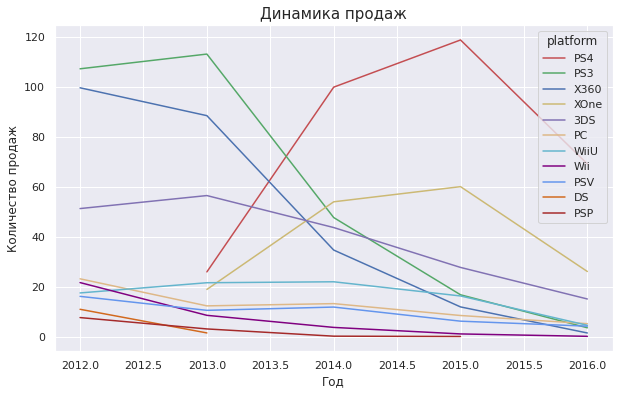

In [34]:
#Создадим сводную таблицу по продажам:
pivot_2012 = df_2012.pivot_table(index=['year_of_release','platform'], values='total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False)

#Отобразим на графике суммарные продажи:
palette = sns.color_palette(['r','g','b','y','m','burlywood','c','purple','cornflowerblue','chocolate','brown'])
ax=sns.lineplot(data=pivot_2012, x='year_of_release', y='total_sales', hue='platform', palette=palette)
ax.set_title('Динамика продаж', fontsize=15)
ax.set_xlabel('Год')
ax.set_ylabel('Количество продаж')
#sns.set_palette('CMRmap')

plt.show()

По условиям, на момент проведения анализа у нас данные не за полный 2016 год, соответственно, за 2016 год мы не будем рассматривать данные отвечая на вопрос падают ли продажи или растут:<br>
В целом, большая часть платформ проседает по продажам по сравнению с предыдущим годом (2015 по отношению к 2014), исключения только `PS4` и `XOne`, будем считать, что в 2016 году их продажи еще дотянутся до уровня 2015 года, даже "переплюнут", учитывая, что продажи игр этих платформ начались в 2013 году и пик прогнозируется в 2018. <br><br>
<b>просто мысль:
</b><br>
В принципе, исходя из того, что игры платформ PS4 и XOne в статистике появились в 2013 году, за анализируемый период можно было взять период не с 2012, а с 2013, но я ничего менять не буду. 

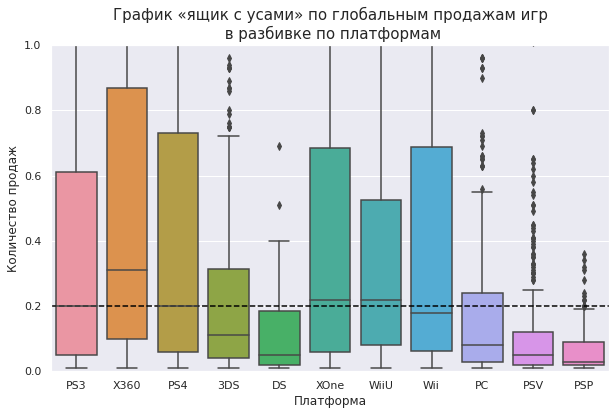

In [36]:
ax=sns.boxplot(data=df_2012, x='platform', y='total_sales')
ax.set_title('График «ящик с усами» по глобальным продажам игр\n в разбивке по платформам', fontsize=15)
ax.set_xlabel('Платформа')
ax.set_ylabel('Количество продаж')
ax.set_ylim(0, 1)
ax.axhline(y=.2, color='black', linestyle='--')
plt.show()

Каждая платформа имеет выбросы с аномальными продажами (отмечено еще на 1 этапе проекта), большая часть игр продавалась менее 1 млн. копий (также отмечалось), медиана редко достигает, а еще реже превышает 0.2 млн.копий. Привлекательнее всего график у X360.

In [37]:
df_2012.pivot_table(index='platform', values='total_sales', aggfunc=['median','mean','count']).droplevel(1,axis=1).sort_values(by='median', ascending=False).head(6).T

platform,X360,WiiU,XOne,PS4,PS3,Wii
median,0.31,0.22,0.22,0.20,0.20,0.18
mean,0.81,0.56,0.65,0.80,0.59,0.66
count,292.00,147.00,247.00,392.00,492.00,54.00


<b>Дополнение:</b><br>
Самыми успешными по качеству (медианное количество проданных копий), а местами количеству игр платформами можно назвать (за 2012-2016 гг.):
1. X360 ~ 310 тыс. копий каждой игры / на 3м месте по количеству продаваемых игр
2. WiiU ~ 220 тыс. копий каждой игры
3. XOne ~ 220 тыс. копий каждой игры / на 4м месте по количеству продаваемых игр
4. PS4 ~ 200 тыс. копий каждой игры / на 2м месте по количеству продаваемых игр 
5. PS3 ~ 200 тыс. копий каждой игры / рекордсмен по количеству продаваемых игр
6. Wii ~ 180 тыс. копий каждой игры

Определим топовые платформы за анализируемый период:

In [38]:
df_2012.pivot_table(index='platform', values='total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False)

,total_sales
platform,
PS4,314.14
PS3,288.78
X360,236.54
3DS,194.61
XOne,159.32
WiiU,82.19
PC,62.65
PSV,49.18
Wii,35.37


Полагаю, имеет смысл рассмотреть первые 5-топ платформ, прочие проигнорировать. Рассмотрим влияние критиков и пользователей на продажи игр:

In [39]:
#Создадим список топ-5 платформ:
top_platforms_2012 = df_2012.pivot_table(index='platform', values='total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False).head(5).index.tolist()

#Отфильтруем "затычки" по колонке "user_score":
filtered_user_srore = df_2012[df_2012['user_score']>0]

#Отфильтруем "затычки" по колонке "critic_score":
filtered_critic_score = df_2012[df_2012['critic_score']>0]

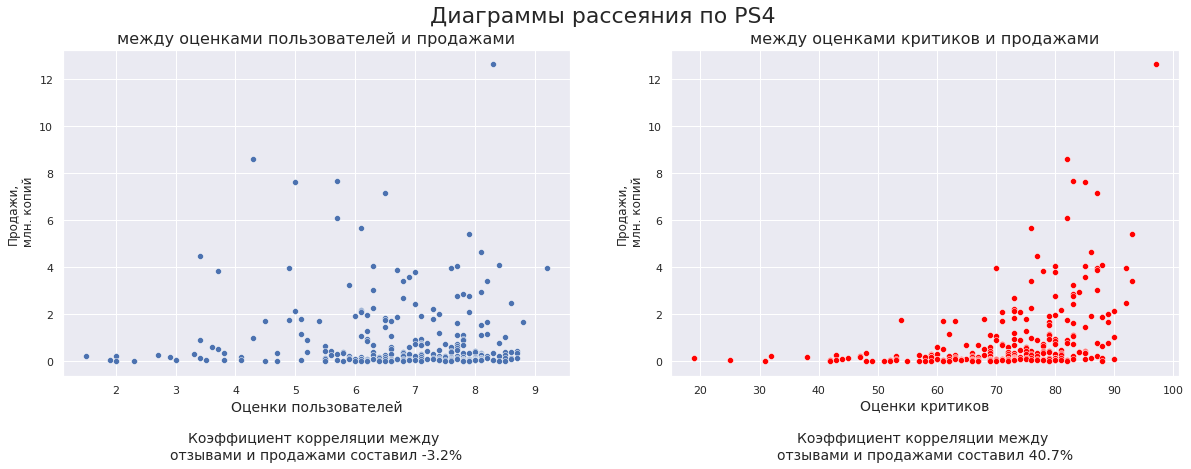

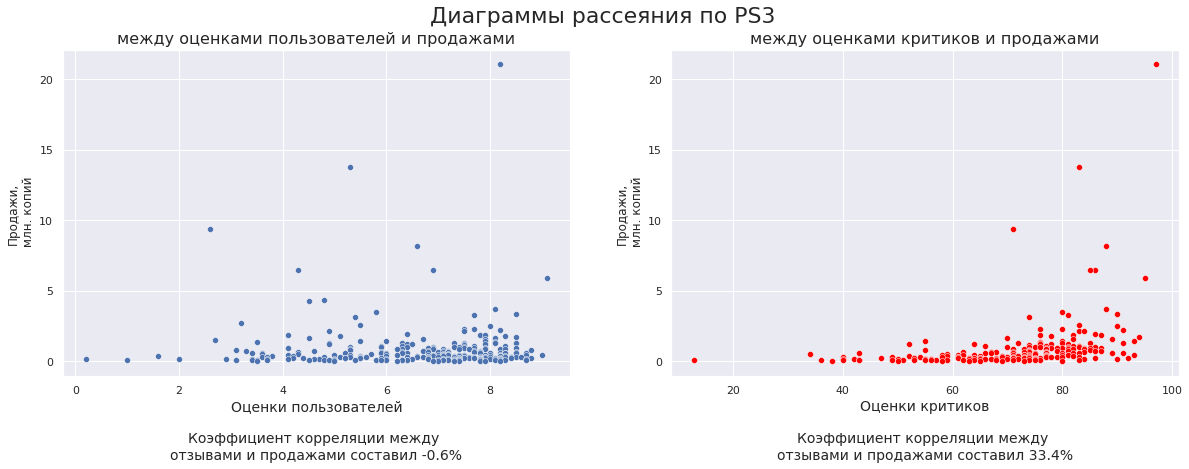

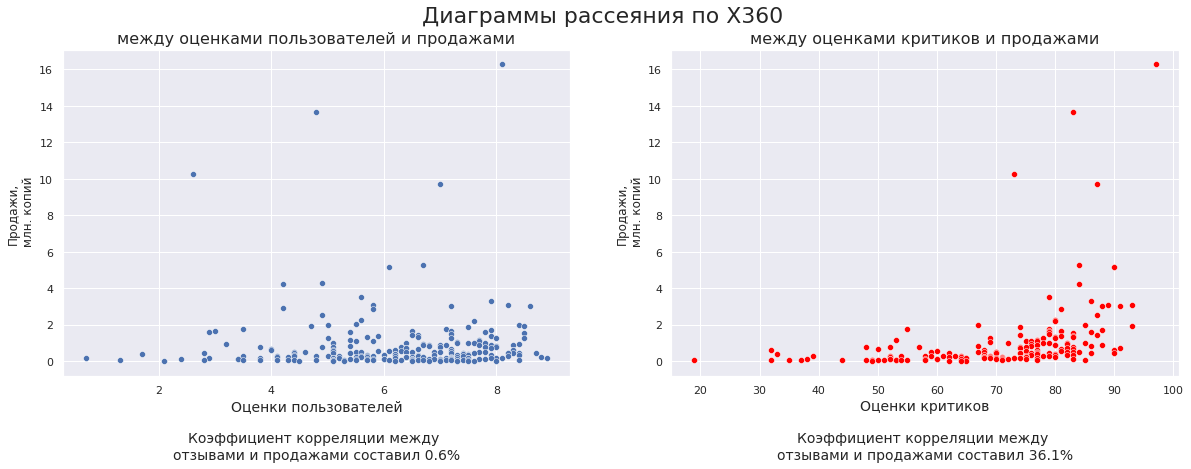

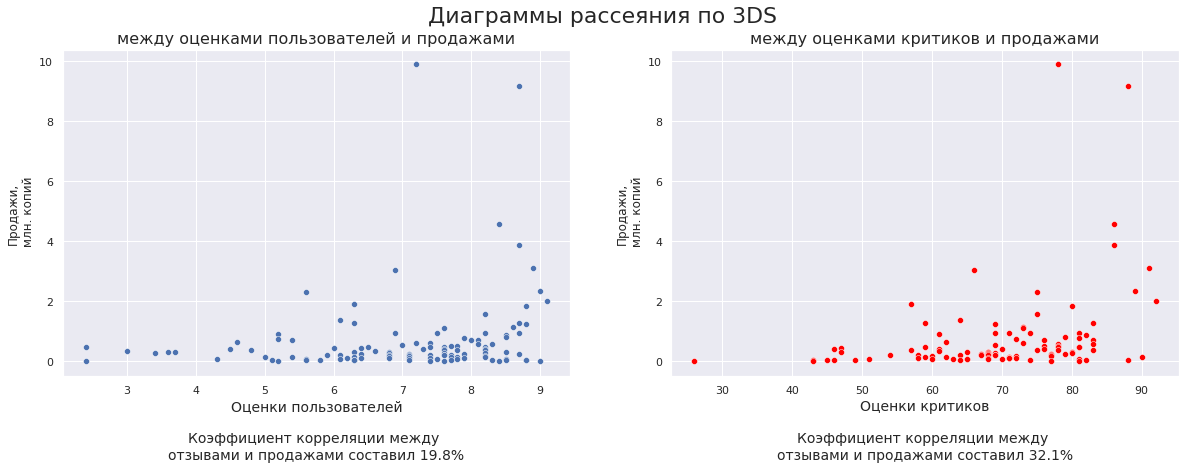

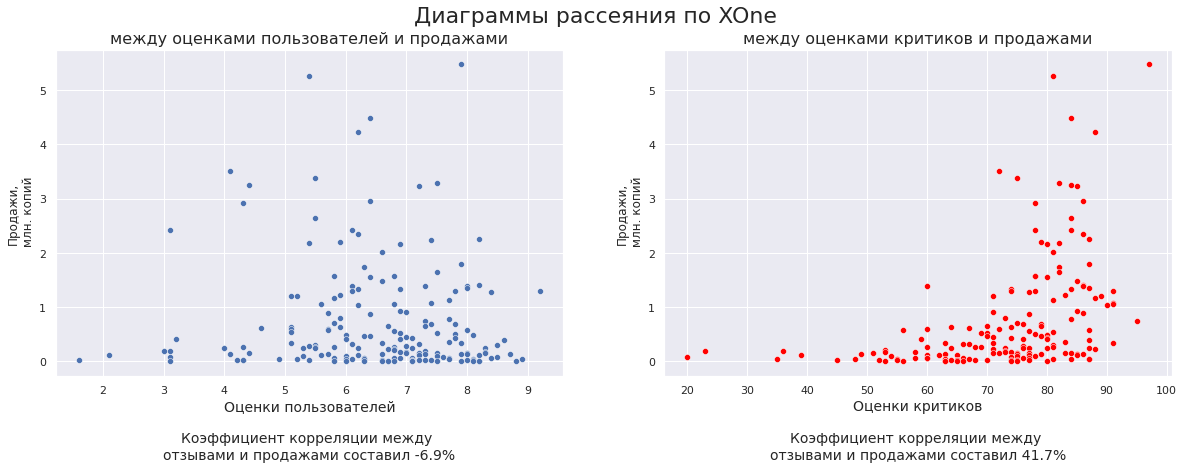

In [40]:
#Отобразим на графиках:

for top in top_platforms_2012:
    #Подсчёт коэффициента корреляции:
    user_coef= filtered_user_srore[filtered_user_srore['platform']==top]['user_score'].corr(filtered_user_srore[filtered_user_srore['platform']==top]['total_sales'])
    critic_coef= filtered_critic_score[filtered_critic_score['platform']==top]['critic_score'].corr(filtered_critic_score[filtered_critic_score['platform']==top]['total_sales'])
    
    #Определение поля для графиков:
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    #Вывод графиков:
    ax[0] = sns.scatterplot(data=filtered_user_srore[filtered_user_srore['platform']==top], x='user_score', y='total_sales', ax=ax[0])
    ax[1] = sns.scatterplot(data=filtered_critic_score[filtered_critic_score['platform']==top], x='critic_score', y='total_sales', ax=ax[1], color='red')
    
    #Подписи:
    fig.suptitle(f'Диаграммы рассеяния по {top}',fontsize=22)
    
    ax[0].set_title(f'между оценками пользователей и продажами',fontsize=16)
    ax[0].set_xlabel(f'Оценки пользователей\n\nКоэффициент корреляции между \nотзывами и продажами составил {user_coef:.1%}', fontsize=14)   
    ax[0].set_ylabel(f'Продажи,\n млн. копий')  
#    ax[0].set_xlim(0,10)
#    ax[0].set_ylim(0,20) 
    ax[1].set_title(f'между оценками критиков и продажами', fontsize=16)
    ax[1].set_xlabel(f'Оценки критиков\n\nКоэффициент корреляции между \nотзывами и продажами составил {critic_coef:.1%}', fontsize=14) 
    ax[1].set_ylabel(f'Продажи,\n млн. копий')   
#    ax[1].set_xlim(0,100)
#    ax[1].set_ylim(0,20)
    
    plt.show()


По графикам, а также коэффициентам корреляции можно отметить, что влияние оценок критиков слабо коррелирует с продажами, отзывы пользователей вообще никакого влияния на продажи не несут.

Рассмотрим сколько всего было создано игр с 2012 года без привязки к платформам (одну игру на нескольких платформах будем считать одной игрой).

In [41]:
#Рассчитаем количество созданных игр: 
total_games = df_2012[['name', 'genre']].drop_duplicates()
for_pie_games = total_games.pivot_table(index='genre', values='name', aggfunc='count').rename(columns={'name':'count'}).sort_values(by='count',ascending=False)
for_pie_games.head(5)


,count
genre,
Action,574
Role-Playing,265
Adventure,216
Misc,130
Sports,99


Визуализируем на графике игры каких жанров создавались и в каком количестве:

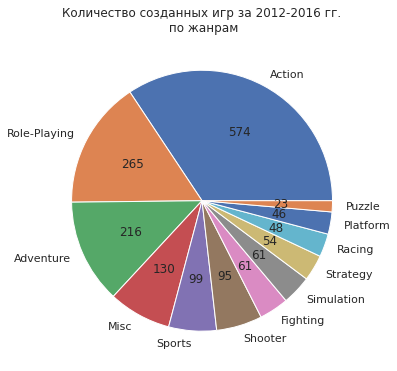

In [42]:
plt.pie(data=for_pie_games,x=for_pie_games['count'], labels=for_pie_games.index, 
        autopct=lambda p : '{:,.0f}'.format(p * sum(for_pie_games['count'])/100))
plt.title('Количество созданных игр за 2012-2016 гг.\n по жанрам')
plt.show()

Рассмотрим продажи игр по жанрам.

In [43]:
#Рассчитаем:
top_genres_sales = df_2012.pivot_table(index='genre', values='total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False)

#выведем 5 лучших жанров
top_genres_sales.head(5)

,total_sales
genre,
Action,441.12
Shooter,304.73
Role-Playing,192.80
Sports,181.06
Misc,85.04


Визуализируем на графике суммарные продажи по всем жанрам:

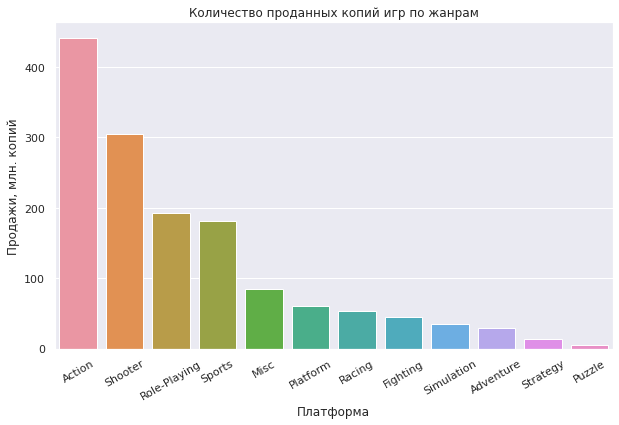

In [44]:
ax = sns.barplot(data=top_genres_sales.T)
ax.set_title('Количество проданных копий игр по жанрам')
ax.set_xlabel('Платформа')
ax.set_ylabel('Продажи, млн. копий')
plt.xticks(rotation=30)
plt.show()

Для определение наиболее прибыльного жанра нужно посмотреть не только общие продажи, но ещё среднее и медиану. Таким способом мы сможем найти жанр, где игры стабильно приносят высокий доход отбросив игры с низкими продажами:

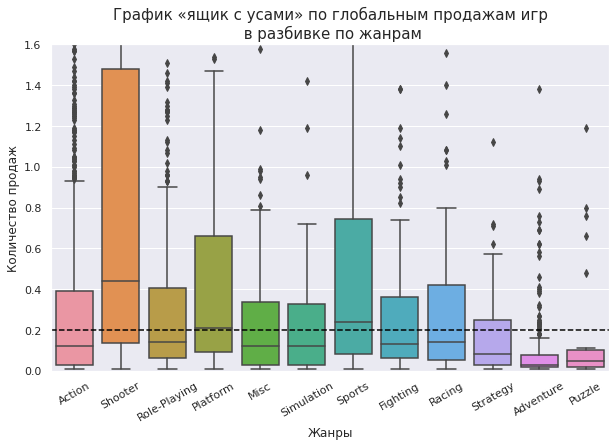

In [45]:
ax=sns.boxplot(data=df_2012, x='genre', y='total_sales')
ax.set_title('График «ящик с усами» по глобальным продажам игр\n в разбивке по жанрам', fontsize=15)
ax.set_xlabel('Жанры')
ax.set_ylabel('Количество продаж')
ax.set_ylim(0,1.6)
ax.axhline(y=.2, color='black', linestyle='--')
plt.xticks(rotation=30)
plt.show()

In [46]:
df_2012.pivot_table(index='genre', values='total_sales', aggfunc=['median','mean','count']).droplevel(1,axis=1).sort_values(by='median', ascending=False).head(6).T

genre,Shooter,Sports,Platform,Racing,Role-Playing,Fighting
median,0.44,0.24,0.21,0.14,0.14,0.13
mean,1.30,0.68,0.72,0.47,0.52,0.41
count,235.00,267.00,85.00,115.00,370.00,109.00


Самыми продаваемыми являются следующие жанры:
1. `Action`	
2. `Shooter`
3. `Role-Playing`
4. `Sports`

<b>Дополнение:</b><br>
Самыми прибыльными являются:
1. `Shooter`
2. `Sports`
3. `Platform`

`Puzzle`,  является самым не продаваемым и не прибыльным жанром. 


<b>
Выводы:</b><br>

Полагаю, из всей базы, актуальным для анализа истории всех платформ, можно считать период 1994-2016гг., при этом помня, что 2016 год еще не полностью в базе.<br>  
Периодом актуального существования платформы можно считать 10 лет, при этом первые 5 лет интерес к приставке растет, а затем, 5 лет снижается.<br>  
Если рассматривать период последних лет в базе, актуальным можно считать период с 2012 года, т.к. он затрагивает историю всех актуальных платформ наиболее полно.<br>  
За период 2012-2016 лидерами продаж игр являются PS4, PS3, X360, 3DS, XOne, при этом потенциально прибыльными несомненно являются PS4 и XOne, их пик прогнозируется в 2018 году.<br>  
Судя по графику «ящик с усами», у каждой платформы имеется огромное число игр всплесков, продажи которой превышают миллионы копий, при этом ни у одной платформы 3 квантиль не достигает и 1млн.копий., а медиана продаж всех игр большинства платформ не достигает 200тыс. копий. Лучше всех, в сравнении с другими платформами выглядит X360.<br>  
Судя по графикам рассеяния, оценки пользователей никак не влияют на продажи, однако отзывы критиков имеют не высокую корреляцию с продажами. <br>  
Самым продаваемыми жанрами можно считать "Action" 441 млн.копий, далее "Shooter" -304 млн.копий, "Role-Playing" - 193 млн.копий, "Sports" - 181 млн.копий, "Misc" - 85 млн. проданных копий. Самыми прибыльными являются "Shooter", "Sports", "Platform".
3-ка худших: "Adventure", "Strategy", "Puzzle" (в некоторые на консолях тяжело играть (стратегии), некоторые как пазлы или приключения не так популярны сами по себе). 

## Шаг. Составить портрет пользователя каждого региона

In [47]:
# Зададим функцию для создания временных таблиц, их объединения, вывода графика:
#Создал 3 временные сводные таблицы:
def create_graph(column, title):
    temp_na=df_2012.pivot_table(index=column, values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False).rename(columns={'na_sales':'sales'}).reset_index().head(5)
    temp_eu=df_2012.pivot_table(index=column, values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False).rename(columns={'eu_sales':'sales'}).reset_index().head(5)
    temp_jp=df_2012.pivot_table(index=column, values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False).rename(columns={'jp_sales':'sales'}).reset_index().head(5)

#Добавил данные с названием региона:
    temp_na['region']='Северная Америка'
    temp_eu['region']='Европа'
    temp_jp['region']='Япония'

#Объединил в единую сводную таблицу:
    df=pd.concat([temp_na,temp_eu,temp_jp])
    
#Вывел всё в одном графике с разбивкой колонке и регионам:
    ax=sns.barplot(data=df, hue=df[column], y='sales', x='region')
    ax.set_title(title)
    ax.set_xlabel('Регион')
    ax.set_ylabel('Продажи, \nмлн. копий')

    plt.show()

Начнем с предпочитаемых платформ:

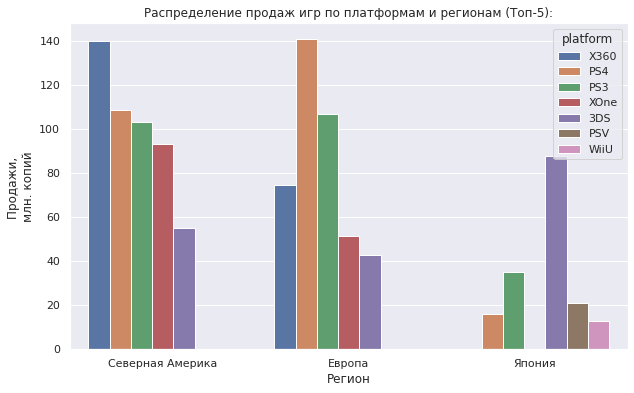

In [48]:
create_graph('platform','Распределение продаж игр по платформам и регионам (Топ-5):')


Как видно из графика, в Северной Америке и Европе одни и теже платформы пользуются популярностью, разница только в том, что в Европе больше предпочитают PS4 (производство Япония), а в Северной Америке X360 (производство Северная Америка).
Японский же регион предпочитает продукцию компаний Nintendo и Sony (местное производство), прочих платформ среди Топ не обнаружено.<br>

Продолжим анализом жанров

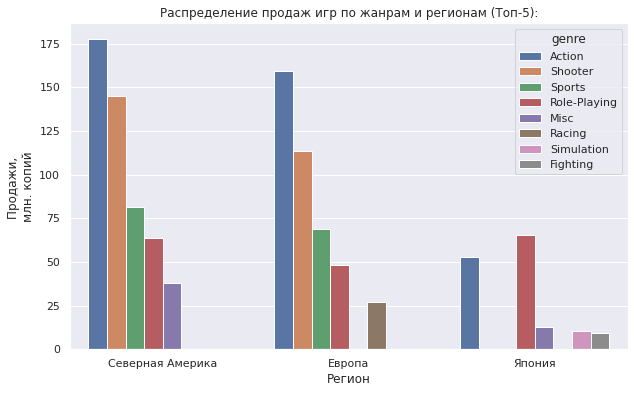

In [49]:
create_graph('genre','Распределение продаж игр по жанрам и регионам (Топ-5):')


По регионам Северная Америка и Европа снова картина схожая по топ-5 жанров, различие только в самом "незначительном" жанре.
А в Японии в принципе, соотношение совершенно другое. Преобладает жанр, который в других регионах почти закрывает топ и только на втором месте жанр, который в Северной Америке и Европе преобладает многократно, стрелялки и спортивные симуляторые в Японский топ в принципе не попали, но попали крайне не популярные для Северной Америки и Европы "симуляторы" и "драки".

Рассмотрим рейтинги игр от организации ESRB (распределение по возрастам), который чаще продавались по регионам:

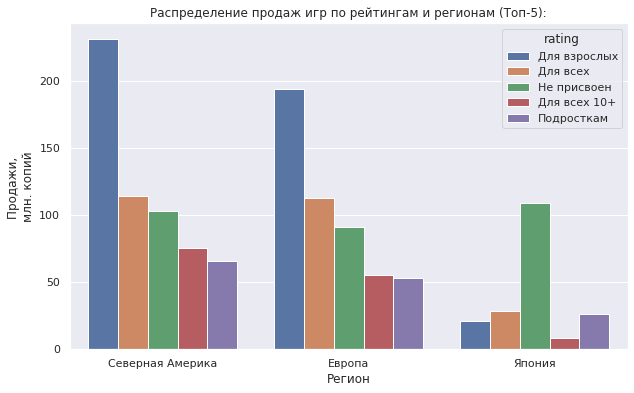

In [50]:
#Создадим словарь с актуальными рейтингами:
rating_dict = {'M':'Для взрослых', 
                'E':'Для всех', 
                'E10+':'Для всех 10+', 
                'T':'Подросткам',
                'no_rating':'Не присвоен'}
#Переименуем рейтинги в дф для лучшего понимания графика:
for key, value in rating_dict.items():
    df_2012['rating'] = df_2012['rating'].replace(key, value)

#Визуализируем с какими рейтингами игры лучше продавались:
create_graph('rating', 'Распределение продаж игр по рейтингам и регионам (Топ-5):')

Снова у Северной Америки и Европы график выглядит похожим образом - большей популярностью пользуются игры с рейтингом `для взрослых`, где преобладает насилие и кровь, далее игры `для всех возрастов` и `без присвоенного рейтинга` (либо не успели присвоить, либо снова для всех), далее идут `рейтинги 10+` и `для подростков`.<br>
Опуская игры `без рейтинга`, по Японии можно отметить, что там преобретают игры в первую очередь `без возрастных ограничений`, далее `для подростков` и только после этого уже `для взрослых`, в отличие от прочих регионов.

<b>
Выводы:</b><br>

В целом, портрет пользователей регионов Северной Америки и Европы очень схожи почти во всём, Японский же регион вообще иначе выглядит во всех аспектах:<br>
Платформы:<br>
У Северной Америки: X360, PS4, PS3, XOne, 3DS (отдают предпочтение местному производителю, потом уже импортным приставкам). <br>
У Европы: PS4, PS3, X360, XOne, 3DS (местного производителя нет, на первом месте Японские платформы, потом Северной Америки).<br>
У Японии: 3DS, PS3, PSV, PS4, WiiU (Топ состоит исключительно из платформ местного производства (SONY и Nintendo)<br>

Жанры:<br>
Тут у Северной Америки и Европы еще больше общего: 1 место - "Action", 2 - "Shooter", 3 - "Sports", 4 - "Role-Playing", 5 у СА - "Мisc", у Европы - "Racing".<br>
Япония снова отличилась: 1 - "Role-Playing", 2 - "Action", 3 - "Мisc", 4 - "Simulation", 5 - "Fithing"
Разница, полагаю связана с разными менталитетами.

Рейтинг ESRB (опустим игры без присвоенного рейтинга):<br>
У Северной Америки и Европы вообще никакой разницы нет, полная идентичность:
1 место - "игры для взрослых" (с повышенной жестокостью), 2 место - "игры для всех", 3 - "10 лет и старше", 4 - "для подростков".<br>
Япония снова отличается:
1 место - "для всех", 2 - "для подростков", 3 - "для взрослых", 4 - "10 лет и старше".

Обобщая: 
В целом, портрет пользователей Северной Америки и Европы очень похож, т.к., вероятно, даже общаются на одном языке, имеют общие традиции, историю. Пользователь-Японец же с ними почти ничего общего не имеет даже в жизни (история, традиции, язык). 

## Шаг. Проверить гипотезы

<b>Сформулируем гипотезы: </b> <br>
<b>Нулевая:  </b> в средних пользовательских рейтингах платформ Xbox One и PC нет значимого различия.<br>
<b>Альтернативная:  </b>в средних пользовательских рейтингах платформ Xbox One и PC есть значимые различия.

Из предудыщих шагов известно, что информация по играм на XOne есть только с 2013 года, а на платформу PC существует информация на 2012 год и ранее, ничего менять не буду, рассмотрю как есть, но приму к сведению. Также, проверю количество записей по платформе XOne и PC в датафрейме (если что, применю "equal_var=False" при проверке гипотез).

In [51]:
#Создадим выборки по платформам для проведения анализа:
pc = df_2012[(df_2012['platform']=='PC')&(df_2012['user_score']>-1)]
xone = df_2012[(df_2012['platform']=='XOne')&(df_2012['user_score']>-1)]
 
print(f'количество записей по платформе PC - {len(pc)}')
print(f'количество записей по платформе XOne - {len(xone)}')

количество записей по платформе PC - 206
количество записей по платформе XOne - 182


In [52]:
#Проверим гипотезы:
alpha = 0.05

results = st.ttest_ind(pc['user_score'], xone['user_score'], equal_var=False, alternative='two-sided')

print(results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

0.5489560463017016
Не получилось отвергнуть нулевую гипотезу


<b>Сформулируем гипотезы: </b> <br>
<b>Нулевая:  </b> в средних пользовательских рейтингах жанров Action и Sports нет значимых различий.<br>
<b>Альтернативная:  </b>в средних пользовательских рейтингах жанров Action и Sports есть значимые различия.

In [53]:
#Создадим выборки по платформам для проведения анализа:
action = df_2012[(df_2012['genre']=='Action')&(df_2012['user_score']>-1)]
sports = df_2012[(df_2012['genre']=='Sports')&(df_2012['user_score']>-1)]
 
print(f'количество записей по платформе Action - {len(action)}')
print(f'количество записей по платформе Sports - {len(sports)}')

количество записей по платформе Action - 523
количество записей по платформе Sports - 194


In [54]:
#Проверим гипотезы:
alpha = 0.05

results = st.ttest_ind(action['user_score'], sports['user_score'], equal_var=False, alternative='two-sided')

print(results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

5.989172574568752e-20
Отвергаем нулевую гипотезу


<b>Вывод:</b><br>
Были проведены 2 теста:
1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.
2. Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

Пороговое значение (`alpha`) было использовано 0.05.<br>
Нулевая гипотеза была сформирована таким образом, что разница между рейтингами не существенная. <br>
Альтернативная гипотеза должна была утверждать, что разница в рейтингах значительна.<br>
При проверка гипотез использовался метод `t-критерий Стьюдента`, было применено `equal_var=False` (`t-тест Уэлша`), т.к. размеры выборок не соответствовали друг другу. Также использовалась в обоих случаях `alternative='two-sided'` - означает, что средние значения распределений, из которых взяты выборки, не равны.

<b>Результаты тестов:</b><br>
1. `Не получилось отвергнуть нулевую гипотезу` - в средних пользовательских рейтингах платформ Xbox One и PC нет значимого различия.
2. `Отвергаем нулевую гипотезу` - в средних пользовательских рейтингах жанров Action и Sports есть значимые различия.

# Общие выводы:
<b>1. Чтение файла с данными, изучение общей информации.</b>
 * Файл был прочитан, изучен, сделаны первые выводы.

<b>2. Подготовка данных:</b>
 * Названия колонок приведены к нижнему регистру.
 * Проверил можно ли подтянуть недостающую информацию от тех же игр, но на других платформах - нельзя.
 * Заполнил "заглушками" отстутствующие поля в записях.
 * Присвоил колонкам корректные типы данных.
 * Добавил колонку с суммарными продажами по всем регионам.
 * Отфильтровал часть дф с играми без присвоенного года выпуска.

<b>3. Исследовательский анализ данных.<br></b>
 * Периодом актуального существования платформы можно считать 10 лет, при этом первые 5 лет интерес к приставке растет, а затем, 5 лет снижается.
 * Если рассматривать период последних лет в базе, актуальным можно считать период с 2012 года, т.к. он затрагивает историю всех актуальных платформ наиболее полно.
 * За указанный период лидерами продаж игр являются PS4, PS3, X360, 3DS, XOne, при этом потенциально прибыльными несомненно являются PS4 и XOne, их пик прогнозируется в 2018 году.
 * У каждой платформы имеется огромное число игр всплесков, продажи которой превышают миллионы копий, при этом ни у одной платформы 3 квантиль не достигает и 1млн.копий, cамыми успешными платформами можно назвать X360, WiiU, XOne, PS4, PS3, Wii.
 * Оценки пользователей никак не влияют на продажи, однако отзывы критиков имеют не высокую корреляцию с продажами.
 * Самым продаваемыми жанрами можно считать "Action" 441 млн.копий, далее "Shooter" - 304 млн.копий, "Role-Playing" - 193 млн.копий, "Sports" - 181 млн.копий, "Misc" - 85 млн. проданных копий. Самыми прибыльными являются: `Shooter`, `Sports`, `Platform`. `Puzzle`,  является самым не продаваемым и не прибыльным жанром из всех.
 
<b>4. Составить портрет пользователя каждого региона.<br></b>
 * В целом, портрет пользователей Северной Америки и Европы очень похож (платформы, жанры, рейтинг игр), т.к., вероятно, даже общаются на одном или похожих языках, имеют общие традиции, историю. Пользователь-Японец же с ними почти ничего общего не имеет даже в жизни (история, традиции, язык) - платформы исключительно "местного производителя" в топе, жанры отличаются координально, игры предпочитает для всех или подростков (Европа и Северная Америка - для взрослых).

<b>5. Проверить гипотезы.<br></b>
Были проведены 2 теста, итоги:
 * В средних пользовательских рейтингах платформ Xbox One и PC нет значимого различия (нулевая гипотеза не отвергнута).
 * В средних пользовательских рейтингах жанров Action и Sports есть значимые различия (нулевая гипотеза отвергнута).